# 19 — Policy Gradients and REINFORCE from Scratch

## Goal

A stochastic policy can sample discrete actions.

The sampled action itself is not differentiable with respect to the
policy parameters.

However, the probability of sampling that action is differentiable.

This lesson develops the bridge from scalar reward to policy gradients:

1. expected reward as an optimization objective,
2. exact gradients in a tiny enumerable policy,
3. the log-derivative trick,
4. Monte Carlo policy-gradient estimation,
5. REINFORCE,
6. return-weighted log-probabilities,
7. baselines and variance reduction,
8. and the connection to autoregressive language models.

In [1]:
import matplotlib.pyplot as plt
import torch

from llmfp.rl import discounted_returns

## 1. Expected Reward as an Objective

Consider a one-step decision problem with two actions:

$$
\mathcal{A}
=
\{A,B\}.
$$

Their rewards are

$$
R(A)=10,
$$

and

$$
R(B)=0.
$$

A stochastic policy assigns probabilities

$$
\pi_\theta(A)
$$

and

$$
\pi_\theta(B).
$$

The objective is not the reward from one sampled action.

It is the expected reward:

$$
J(\theta)
=
\mathbb{E}_{a\sim\pi_\theta}
[R(a)].
$$

Because the action space is tiny, we can enumerate it exactly:

$$
J(\theta)
=
\sum_a
\pi_\theta(a)R(a).
$$

### A One-Parameter Policy

Let the policy logits be

$$
z
=
[\theta,0].
$$

Applying softmax gives

$$
\pi_\theta(A)
=
\frac{e^\theta}
{e^\theta+1},
$$

and

$$
\pi_\theta(B)
=
\frac{1}
{e^\theta+1}.
$$

Increasing $\theta$ increases the probability of action $A$.

In [2]:
theta = torch.tensor(-0.8473, requires_grad=True)

logits: torch.Tensor = torch.stack([theta, torch.tensor(0.0)])

probabilities: torch.Tensor = torch.softmax(logits, dim=0)

rewards: torch.Tensor = torch.tensor([10.0, 0.0])

expected_reward: torch.Tensor = torch.sum(probabilities * rewards)

print("probabilities:", probabilities)

print("expected reward:", expected_reward.item())

probabilities: tensor([0.3000, 0.7000], grad_fn=<SoftmaxBackward0>)
expected reward: 2.999995708465576


In [3]:
expected_reward.backward()

print("dJ/dtheta:", theta.grad.item())

dJ/dtheta: 2.0999982357025146


In [4]:
probability_a: float = probabilities[0].detach().item()

manual_gradient: float = 10.0 * probability_a * (1.0 - probability_a)

print("manual gradient:", manual_gradient)

print("autograd gradient:", theta.grad.item())

assert abs(manual_gradient - theta.grad.item()) < 1e-5

manual gradient: 2.0999982595424793
autograd gradient: 2.0999982357025146


### The Real Difficulty

The expected reward can be differentiated exactly when every possible
action and reward can be enumerated.

The difficulty appears when the action or trajectory space is too large
to sum over explicitly.

For a language model, the number of possible generated sequences is
astronomical.

We therefore need to estimate

$$
\nabla_\theta J(\theta)
$$

using trajectories sampled from the policy itself.

The next question is:

> How can a sampled discrete action provide an unbiased estimate of the
> gradient of expected reward?

## 2. From the Exact Gradient to a Sampleable Gradient

For the one-step decision problem,

$$
J(\theta)
=
\mathbb{E}_{a\sim\pi_\theta}
[R(a)].
$$

If all actions can be enumerated,

$$
J(\theta)
=
\sum_a
\pi_\theta(a)R(a).
$$

Differentiating gives

$$
\nabla_\theta J(\theta)
=
\sum_a
R(a)
\nabla_\theta
\pi_\theta(a).
$$

This gradient is exact, but it still requires summing over every action.

The goal is to rewrite it as an expectation that can be estimated by
sampling actions from the policy.

### The Log-Derivative Trick

For any positive differentiable function $f(\theta)$,

$$
\nabla_\theta \log f(\theta)
=
\frac{
\nabla_\theta f(\theta)
}{
f(\theta)
}.
$$

Rearranging gives

$$
\nabla_\theta f(\theta)
=
f(\theta)
\nabla_\theta
\log f(\theta).
$$

Setting

$$
f(\theta)
=
\pi_\theta(a)
$$

gives

$$
\nabla_\theta
\pi_\theta(a)
=
\pi_\theta(a)
\nabla_\theta
\log
\pi_\theta(a).
$$

This identity is the bridge that turns an exact sum over probability
gradients into an expectation over sampled actions.

### A Single Sample Is Noisy but Unbiased

For the current policy,

$$
\pi(A)=0.3,
\qquad
\pi(B)=0.7.
$$

The score gradients are

$$
\frac{d}{d\theta}
\log\pi(A)
=
1-\pi(A)
=
0.7,
$$

and

$$
\frac{d}{d\theta}
\log\pi(B)
=
-\pi(A)
=
-0.3.
$$

If action $A$ is sampled,

$$
\hat g_A
=
R(A)
\frac{d}{d\theta}
\log\pi(A)
=
10(0.7)
=
7.
$$

If action $B$ is sampled,

$$
\hat g_B
=
0(-0.3)
=
0.
$$

Neither single outcome needs to equal the exact gradient.

But their expectation does:

$$
\mathbb E[\hat g]
=
0.3(7)
+
0.7(0)
=
2.1.
$$

This equals the exact gradient

$$
\frac{dJ}{d\theta}
=
2.1.
$$

In [5]:
theta = torch.tensor(-0.8473, requires_grad=True)

logits: torch.Tensor = torch.stack([theta, torch.tensor(0.0)])

log_probabilities: torch.Tensor = torch.log_softmax(logits, dim=0)

print("log probabilities:", log_probabilities)

log probabilities: tensor([-1.2040, -0.3567], grad_fn=<LogSoftmaxBackward0>)


In [6]:
gradient_a = torch.autograd.grad(
    log_probabilities[0], theta, retain_graph=True
)[0]

print("d log pi(A) / d theta:", gradient_a.item())

d log pi(A) / d theta: 0.7000004053115845


In [7]:
gradient_b = torch.autograd.grad(log_probabilities[1], theta)[0]

print("d log pi(B) / d theta:", gradient_b.item())

d log pi(B) / d theta: -0.29999956488609314


In [8]:
probabilities = torch.tensor([0.3, 0.7])

rewards = torch.tensor([10.0, 0.0])

score_gradients = torch.tensor([0.7, -0.3])


torch.manual_seed(0)

num_samples: int = 10_000

sampled_actions: torch.Tensor = torch.multinomial(
    probabilities, num_samples=num_samples, replacement=True
)

gradient_estimates: torch.Tensor = (
    rewards[sampled_actions] * score_gradients[sampled_actions]
)

monte_carlo_gradient: float = gradient_estimates.mean().item()

print("Monte Carlo gradient estimate:", monte_carlo_gradient)

print("Exact gradient:", 2.1)

Monte Carlo gradient estimate: 2.0782999992370605
Exact gradient: 2.1


In [9]:
for num_samples in [10, 100, 1_000, 10_000, 100_000]:
    torch.manual_seed(0)

    sampled_actions = torch.multinomial(
        probabilities, num_samples=num_samples, replacement=True
    )

    estimates = rewards[sampled_actions] * score_gradients[sampled_actions]

    print(f"{num_samples:>6}: {estimates.mean().item():.4f}")

    10: 1.4000
   100: 2.2400
  1000: 2.1630
 10000: 2.0783
100000: 2.1015


### The Gradient Does Not Pass Through the Sample

Policy gradients do not differentiate the sampled action itself.

There is no term

$$
\frac{\partial a}{\partial\theta}.
$$

Instead, the sampled action identifies which differentiable policy
probability should be evaluated:

$$
\log\pi_\theta(a).
$$

The environment reward is then used as a scalar weight:

$$
R(a)
\nabla_\theta
\log\pi_\theta(a).
$$

The gradient therefore passes through the probability of the sampled
action, not through the discrete sampling operation.

In [10]:
# test with the torch.multinomial

probabilities = torch.tensor([0.3, 0.7])

torch.manual_seed(0)

samples = torch.multinomial(probabilities, num_samples=20, replacement=True)

print(samples)

tensor([1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1])


In [11]:
count_a: int = int((samples == 0).sum().item())

count_b: int = int((samples == 1).sum().item())

print(
    "A:",
    count_a,
)

print(
    "B:",
    count_b,
)

A: 4
B: 16


## 3. The REINFORCE Loss

The policy-gradient estimator points in the direction of increasing
expected reward:

$$
R(a)
\nabla_\theta
\log\pi_\theta(a).
$$

PyTorch optimizers perform gradient descent, so we define the surrogate
loss

$$
\mathcal{L}_{\text{REINFORCE}}
=
-
R(a)
\log\pi_\theta(a).
$$

Its gradient is

$$
\nabla_\theta
\mathcal{L}_{\text{REINFORCE}}
=
-
R(a)
\nabla_\theta
\log\pi_\theta(a).
$$

Gradient descent on this loss therefore performs gradient ascent on the
policy objective.

In [12]:
theta = torch.tensor(-0.8473, requires_grad=True)

learning_rate: float = 0.1

optimizer = torch.optim.SGD([theta], lr=learning_rate)

In [13]:
logits: torch.Tensor = torch.stack([theta, torch.tensor(0.0)])

probabilities: torch.Tensor = torch.softmax(logits, dim=0)

log_probabilities: torch.Tensor = torch.log_softmax(logits, dim=0)

print("before:", probabilities.detach())

before: tensor([0.3000, 0.7000])


In [14]:
sampled_action: int = 0

reward: float = 10.0

sampled_log_probability: torch.Tensor = log_probabilities[sampled_action]

loss: torch.Tensor = -reward * sampled_log_probability

print("loss:", loss.item())

loss: 12.039742469787598


In [15]:
optimizer.zero_grad()

loss.backward()

print("theta gradient:", theta.grad.item())

theta gradient: -7.000004291534424


In [16]:
optimizer.step()

new_logits: torch.Tensor = torch.stack([theta, torch.tensor(0.0)])

new_probabilities: torch.Tensor = torch.softmax(new_logits, dim=0)

print("after:", new_probabilities.detach())

after: tensor([0.4632, 0.5368])


In [17]:
theta = torch.tensor(-0.8473, requires_grad=True)

optimizer = torch.optim.SGD([theta], lr=0.1)

action_rewards = torch.tensor([10.0, 0.0])

logits: torch.Tensor = torch.stack([theta, torch.tensor(0.0)])

probabilities: torch.Tensor = torch.softmax(logits, dim=0)

sampled_action_tensor: torch.Tensor = torch.multinomial(
    probabilities.detach(), num_samples=1
)

sampled_action: int = int(sampled_action_tensor.item())

reward: torch.Tensor = action_rewards[sampled_action]

log_probabilities: torch.Tensor = torch.log_softmax(logits, dim=0)

sampled_log_probability: torch.Tensor = log_probabilities[sampled_action]

loss: torch.Tensor = -reward * sampled_log_probability

In [18]:
torch.manual_seed(0)

theta = torch.tensor(-0.8473, requires_grad=True)

optimizer = torch.optim.SGD([theta], lr=0.05)

action_rewards = torch.tensor([10.0, 0.0])

num_steps: int = 200

In [19]:
probability_history: list[float] = []

for step in range(num_steps):
    logits: torch.Tensor = torch.stack([theta, torch.tensor(0.0)])

    probabilities: torch.Tensor = torch.softmax(logits, dim=0)

    sampled_action: int = int(
        torch.multinomial(probabilities.detach(), num_samples=1).item()
    )

    reward: torch.Tensor = action_rewards[sampled_action]

    log_probabilities: torch.Tensor = torch.log_softmax(logits, dim=0)

    sampled_log_probability: torch.Tensor = log_probabilities[sampled_action]

    loss: torch.Tensor = -reward * sampled_log_probability

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    probability_history.append(probabilities[0].detach().item())

In [20]:
final_probabilities: torch.Tensor = torch.softmax(
    torch.stack([theta, torch.tensor(0.0)]),
    dim=0,
)

print("final probabilities:", final_probabilities.detach())

final probabilities: tensor([0.9889, 0.0111])


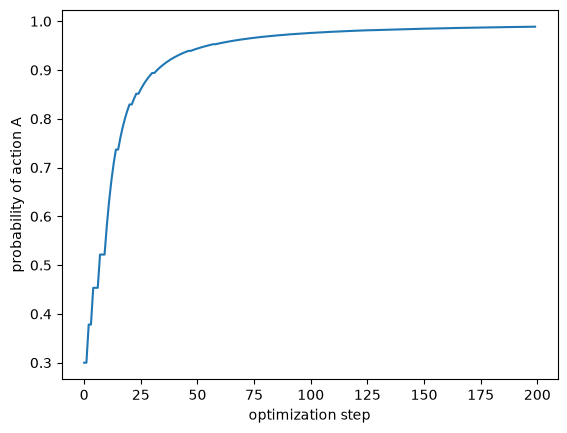

In [21]:
plt.figure()

plt.plot(probability_history)

plt.xlabel("optimization step")

plt.ylabel("probability of action A")

plt.show()

## 4. REINFORCE in a One-Step Environment

For one sampled action,

$$
a
\sim
\pi_\theta,
$$

with observed reward

$$
R(a),
$$

REINFORCE uses the surrogate loss

$$
\mathcal{L}
=
-
R(a)
\log
\pi_\theta(a).
$$

The sampled action itself is treated as a discrete observation.

Gradient flows through the log-probability assigned to that action.

Repeated stochastic updates move probability mass toward actions that
produce higher reward.

## 5. From One Action to a Trajectory

REINFORCE extends naturally from one sampled action to a sequence of
sampled actions.

A trajectory contains

$$
\tau
=
(s_0,a_0,r_0,s_1,a_1,r_1,\ldots).
$$

Under a stochastic policy, the action-dependent part of the trajectory
probability is

$$
P_\theta(\tau)
\propto
\prod_t
\pi_\theta(a_t\mid s_t).
$$

Taking logarithms converts the product into a sum:

$$
\log P_\theta(\tau)
=
\text{environment terms}
+
\sum_t
\log\pi_\theta(a_t\mid s_t).
$$

The environment dynamics do not depend on the policy parameters, so the
policy-dependent gradient is

$$
\nabla_\theta
\log P_\theta(\tau)
=
\sum_t
\nabla_\theta
\log\pi_\theta(a_t\mid s_t).
$$

### Reward-to-Go

An action cannot influence rewards that occurred before that action.

Therefore, instead of weighting every action by the complete episode
return, we can weight action $a_t$ by only the rewards that follow it:

$$
G_t
=
r_t
+
\gamma r_{t+1}
+
\gamma^2r_{t+2}
+
\cdots.
$$

This gives the trajectory REINFORCE surrogate loss

$$
\mathcal{L}_{\text{REINFORCE}}
=
-
\sum_t
G_t
\log
\pi_\theta(a_t\mid s_t).
$$

Reward-to-go improves credit assignment by removing rewards that an
action could not possibly have caused.

In [22]:
rewards: list[float] = [2.0, 0.0, 5.0]

returns: list[float] = discounted_returns(rewards, gamma=1.0)

print(returns)

[7.0, 5.0, 5.0]


In [23]:
log_probabilities = torch.tensor([-0.5, -1.0, -0.2], requires_grad=True)

returns_tensor = torch.tensor(
    returns,
)

reinforce_loss: torch.Tensor = -torch.sum(returns_tensor * log_probabilities)

print(reinforce_loss.item())

9.5


In [24]:
reinforce_loss.backward()

print(log_probabilities.grad)

tensor([-7., -5., -5.])


## 6. Baselines and Variance Reduction

REINFORCE provides an unbiased policy-gradient estimator, but individual
samples can have high variance.

A common idea is to subtract a baseline from the return:

$$
G_t
\rightarrow
G_t-b(s_t).
$$

The surprising fact is that an action-independent baseline can change
the variance of the estimator without changing its expected gradient.

### Why a Baseline Does Not Bias the Policy Gradient

For a baseline $b(s)$ that does not depend on the sampled action,

$$
\mathbb{E}_{a\sim\pi_\theta}
\left[
b(s)
\nabla_\theta
\log\pi_\theta(a\mid s)
\right]
$$

becomes

$$
b(s)
\sum_a
\pi_\theta(a\mid s)
\nabla_\theta
\log\pi_\theta(a\mid s).
$$

Using

$$
\pi_\theta(a\mid s)
\nabla_\theta
\log\pi_\theta(a\mid s)
=
\nabla_\theta
\pi_\theta(a\mid s),
$$

we obtain

$$
b(s)
\nabla_\theta
\sum_a
\pi_\theta(a\mid s).
$$

Since policy probabilities sum to one,

$$
\sum_a
\pi_\theta(a\mid s)
=
1,
$$

so

$$
\nabla_\theta 1
=
0.
$$

Therefore,

$$
\mathbb{E}
\left[
b(s)
\nabla_\theta
\log\pi_\theta(a\mid s)
\right]
=
0.
$$

In [25]:
probability_a: float = 0.3
probability_b: float = 0.7

gradient_a: float = 7.0
gradient_b: float = 0.0

mean_gradient: float = probability_a * gradient_a + probability_b * gradient_b

variance_without_baseline: float = (
    probability_a * gradient_a**2
    + probability_b * gradient_b**2
    - mean_gradient**2
)

print("mean:", mean_gradient)

print("variance without baseline:", variance_without_baseline)

mean: 2.1
variance without baseline: 10.29


In [26]:
baseline_gradient_a: float = (10.0 - 3.0) * 0.7

baseline_gradient_b: float = (0.0 - 3.0) * -0.3

mean_with_baseline: float = (
    probability_a * baseline_gradient_a + probability_b * baseline_gradient_b
)

variance_with_baseline: float = (
    probability_a * baseline_gradient_a**2
    + probability_b * baseline_gradient_b**2
    - mean_with_baseline**2
)

print("mean with baseline:", mean_with_baseline)

print("variance with baseline:", variance_with_baseline)

mean with baseline: 2.0999999999999996
variance with baseline: 3.3599999999999994


### The Value Function as a Baseline

A natural state-dependent baseline is

$$
b(s_t)
=
V^\pi(s_t).
$$

The quantity

$$
G_t
-
V^\pi(s_t)
$$

compares the sampled return with what was expected from that state.

Because

$$
G_t
$$

is a Monte Carlo sample of the return after taking the sampled action,
the difference

$$
\hat A_t
=
G_t
-
V^\pi(s_t)
$$

acts as a Monte Carlo estimate of advantage.

The policy loss can therefore be written as

$$
\mathcal L_{\text{policy}}
=
-
\sum_t
\hat A_t
\log
\pi_\theta(a_t\mid s_t).
$$

## 7. REINFORCE for an Autoregressive Language Model

An autoregressive language model is already a stochastic policy.

At generation step $t$, the state is

$$
s_t
=
(x,y_{<t}),
$$

where $x$ is the prompt and $y_{<t}$ is the generated prefix.

The action is the next token:

$$
a_t
=
y_t.
$$

The policy is the language model's next-token distribution:

$$
\pi_\theta(a_t\mid s_t)
=
p_\theta(
y_t
\mid
x,y_{<t}
).
$$

A generated completion is therefore a sampled trajectory.

### Sequence-Level Reward

If a completion receives a single terminal reward $R$, and

$$
\gamma=1,
$$

then every earlier action has the same reward-to-go:

$$
G_t=R.
$$

The REINFORCE loss becomes

$$
\mathcal L
=
-
R
\sum_t
\log
\pi_\theta(a_t\mid s_t).
$$

Because

$$
\log P_\theta(\tau)
=
\sum_t
\log
\pi_\theta(a_t\mid s_t),
$$

this can also be written as

$$
\mathcal L
=
-
R
\log P_\theta(\tau).
$$

In [27]:
sampled_log_probabilities = torch.tensor([-0.5, -1.0, -0.2], requires_grad=True)

In [28]:
rewards: list[float] = [0.0, 0.0, 5.0]

returns: list[float] = discounted_returns(rewards, gamma=1.0)

returns_tensor = torch.tensor(returns)

print(returns_tensor)

tensor([5., 5., 5.])


In [29]:
policy_loss: torch.Tensor = -torch.sum(
    returns_tensor * sampled_log_probabilities
)

print(policy_loss.item())

8.5


In [30]:
policy_loss.backward()

print(sampled_log_probabilities.grad)

tensor([-5., -5., -5.])


In [31]:
sampled_log_probabilities = torch.tensor([-0.5, -1.0, -0.2], requires_grad=True)

returns_tensor = torch.tensor([5.0, 5.0, 5.0])

values = torch.tensor([4.0, 4.5, 5.2])

advantages: torch.Tensor = returns_tensor - values

print(advantages)

tensor([ 1.0000,  0.5000, -0.2000])


In [32]:
policy_loss: torch.Tensor = -torch.sum(
    advantages.detach() * sampled_log_probabilities
)

policy_loss.backward()

print(sampled_log_probabilities.grad)

tensor([-1.0000, -0.5000,  0.2000])


### Token-Level Credit Assignment

A sequence-level reward can be converted into different learning signals
for different token decisions.

Using a state-value baseline,

$$
\hat A_t
=
G_t
-
V(s_t),
$$

the policy loss becomes

$$
\mathcal L_{\text{policy}}
=
-
\sum_t
\hat A_t
\log
\pi_\theta(a_t\mid s_t).
$$

A positive advantage increases the probability of the sampled token.

A negative advantage decreases it.

The value function therefore helps transform a coarse sequence outcome
into more local credit signals.

## 8. Takeaways

The reinforcement-learning objective is expected return:

$$
J(\theta)
=
\mathbb E_{\tau\sim\pi_\theta}
[
R(\tau)
].
$$

Discrete actions prevent ordinary pathwise differentiation through the
sample itself.

The log-derivative identity

$$
\nabla_\theta
\pi_\theta(a)
=
\pi_\theta(a)
\nabla_\theta
\log
\pi_\theta(a)
$$

rewrites the exact policy gradient as

$$
\nabla_\theta J
=
\mathbb E
\left[
R
\nabla_\theta
\log
\pi_\theta(a)
\right].
$$

This expectation can be estimated from sampled actions or trajectories.

REINFORCE implements the estimator using the surrogate loss

$$
\mathcal L
=
-
R
\log
\pi_\theta(a).
$$

For sequential decisions, reward-to-go gives

$$
\mathcal L
=
-
\sum_t
G_t
\log
\pi_\theta(a_t\mid s_t).
$$

Subtracting an action-independent baseline does not change the expected
policy gradient.

Using the state value as the baseline gives the Monte Carlo advantage
estimate

$$
\hat A_t
=
G_t
-
V(s_t),
$$

and therefore

$$
\mathcal L_{\text{policy}}
=
-
\sum_t
\hat A_t
\log
\pi_\theta(a_t\mid s_t).
$$

For an autoregressive language model:

<pre>
state
    =
prompt + generated prefix

action
    =
sampled next token

policy
    =
next-token distribution

log probability
    =
differentiable trace of why that token was sampled

return / advantage
    =
scalar credit assigned to that token decision
</pre>

Policy gradients do not differentiate through the sampled token.

They differentiate through the probability that the policy assigned to
that sampled token.